# Demonstrate that the FITC objective does eventually approximate the LML

In [3]:
import gpflow as gpf 
import numpy as np
import scipy.stats as ss
import tensorflow as tf 
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm
import os

import sys
sys.path.append("../..")

from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood

In [4]:
def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50, "maxiter": 250})
    plt.plot(res["loss_history"])
    plt.show()

#### Generate data with known parameters
Almost perfect anti-correlation (bar some slight noise), so that should also be what the coregion matrix becomes, $W = \begin{bmatrix}1 \\ -1\end{bmatrix}$ then $WW^T = \begin{bmatrix} 1 & -1 \\ -1 & 1\end{bmatrix}.$

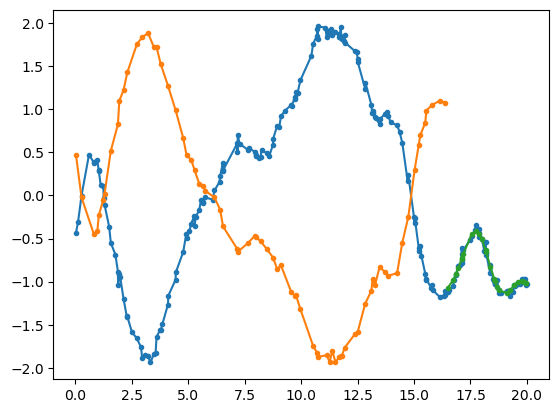

In [5]:
k = gpf.kernels.RBF(lengthscales=1, variance=1) 
Xall = np.sort(np.random.random(200) * 20)
Yall  = np.random.multivariate_normal(np.zeros_like(Xall), k(Xall.reshape(-1, 1)))
ind_1 = np.arange(0, 200, 1)
ind_2 = np.array([i for i in ind_1 if i % 2 == 0])
ind_1 = ind_1
ind_2 = ind_2
TEST_INDEX = int(0.75*len(ind_2))
ind_train, ind_test = ind_2[:TEST_INDEX], ind_2[TEST_INDEX:]
X1, y1 = Xall[ind_1], Yall[ind_1]
X2, y2 = Xall[ind_train], Yall[ind_train]
X2 = X2
y2 = -1*y2
Xtest, ytest = Xall[ind_test], Yall[ind_test]

y1 = y1.reshape(-1, 1) + np.random.normal(0, 0.05, len(X1)).reshape(-1, 1)
y2 = y2.reshape(-1, 1) + np.random.normal(0, 0.05, len(X2)).reshape(-1, 1) 
X1 = X1.reshape(-1, 1)
X2 = X2.reshape(-1, 1)
plt.plot(X1, y1, marker=".")
plt.plot(X2, y2, marker=".")
plt.plot(Xtest, ytest, marker=".")
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
plt.show()
X = tf.cast(X, np.float64)
y = tf.cast(y, np.float64)

In [6]:
exponents = np.arange(2, 13)
superlmls = []
output_dim = 2  # Number of outputs
rank = 1  # Rank of W
cross_cov = np.arange(-1, 1.25, 0.25)
for i in cross_cov:
    lmls = []
    for exponent in exponents:
        print(2 ** exponent)
        k = gpf.kernels.RBF(lengthscales=1)
        coreg = gpf.kernels.Coregion(
            output_dim=output_dim, rank=rank, active_dims=[1]
        )
        coreg.W = np.array([1., i]).reshape(-1, 1)
        kern = k * coreg
        m2 = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
        k = gpf.kernels.RBF(lengthscales=1)

        # Base kernel
        coreg = gpf.kernels.Coregion(
            output_dim=output_dim, rank=rank, active_dims=[1]
        )
        coreg.W = np.array([1., i]).reshape(-1, 1)

        # Coregion kernel
        ivs = np.linspace(0, max(X[:,0]), 2 ** exponent).reshape(-1, 1)
        iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
        shuffle = np.random.permutation(np.arange(len(ivs)))
        iv_ind = iv_ind[shuffle]
        ivs = np.hstack((ivs, iv_ind))
        kern = k * coreg
        m = SparseCMOGP((X, y), exact_target=False, kernel=kern, inducing_variable=ivs, jitter=1e-5, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
        lmls.append((m.maximum_log_likelihood_objective(), m2.maximum_log_likelihood_objective()))
    print(lmls)
    superlmls.append(lmls)
lmls = np.array(superlmls)



4
8
16
32
64
128
256


2026-06-09 16:52:15.612040: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-06-09 16:52:15.800879: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


512


2026-06-09 16:52:16.036954: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


1024


...

1024
2048


2026-06-09 16:52:44.913806: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


4096


2026-06-09 16:52:45.717981: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


[(<tf.Tensor: shape=(), dtype=float64, numpy=-126.61119086713606>, <tf.Tensor: shape=(), dtype=float64, numpy=-89.3309099541357>), (<tf.Tensor: shape=(), dtype=float64, numpy=-129.29822494335085>, <tf.Tensor: shape=(), dtype=float64, numpy=-89.3309099541357>), (<tf.Tensor: shape=(), dtype=float64, numpy=-113.7658074820435>, <tf.Tensor: shape=(), dtype=float64, numpy=-89.3309099541357>), (<tf.Tensor: shape=(), dtype=float64, numpy=-91.58261863906824>, <tf.Tensor: shape=(), dtype=float64, numpy=-89.3309099541357>), (<tf.Tensor: shape=(), dtype=float64, numpy=-89.53042938634297>, <tf.Tensor: shape=(), dtype=float64, numpy=-89.3309099541357>), (<tf.Tensor: shape=(), dtype=float64, numpy=nan>, <tf.Tensor: shape=(), dtype=float64, numpy=-89.3309099541357>), (<tf.Tensor: shape=(), dtype=float64, numpy=nan>, <tf.Tensor: shape=(), dtype=float64, numpy=-89.3309099541357>), (<tf.Tensor: shape=(), dtype=float64, numpy=nan>, <tf.Tensor: shape=(), dtype=float64, numpy=-89.3309099541357>), (<tf.Tenso

(11, 2)


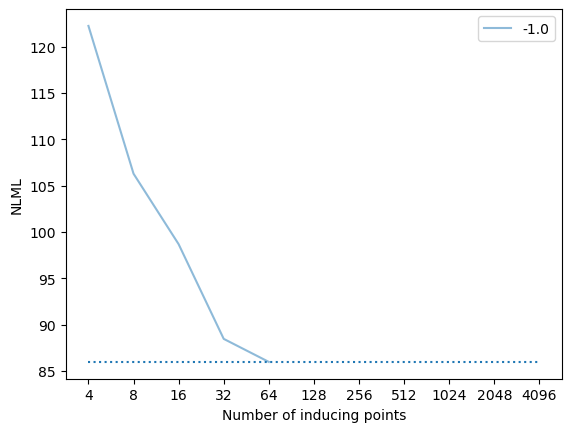

(11, 2)


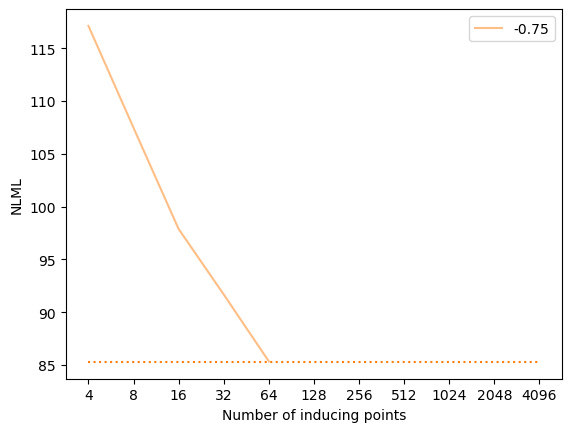

(11, 2)


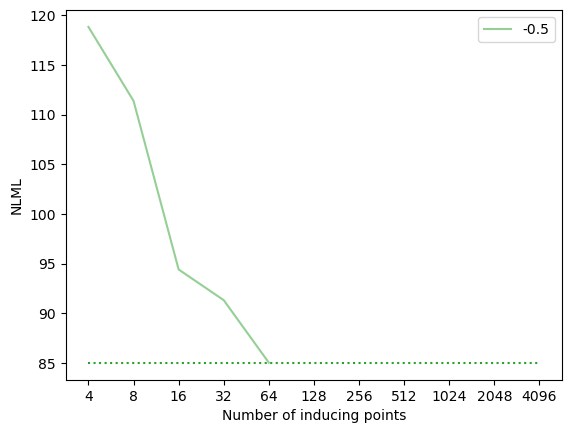

(11, 2)


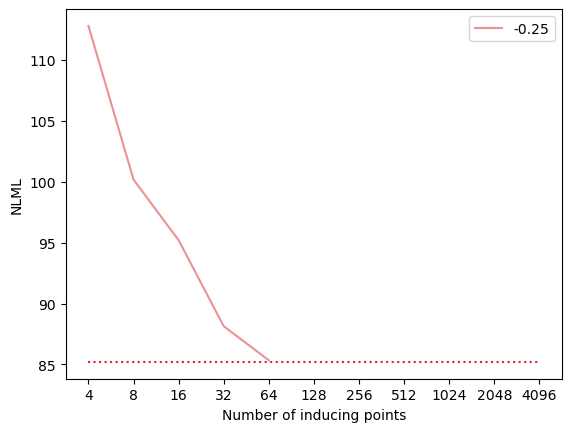

(11, 2)


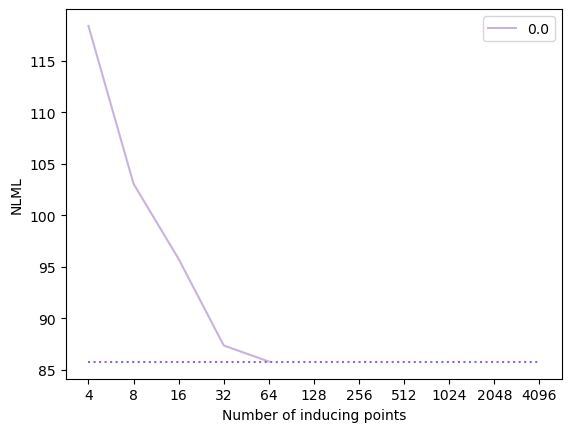

(11, 2)


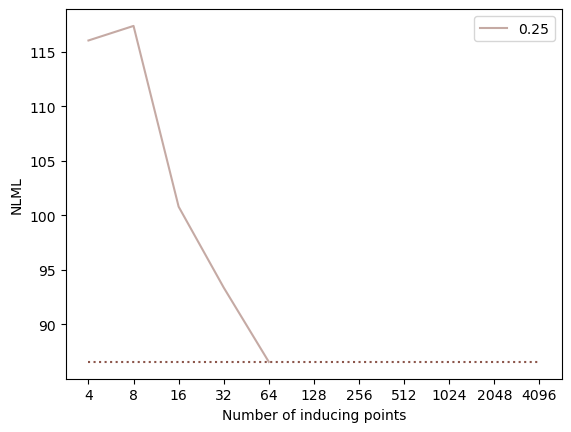

(11, 2)


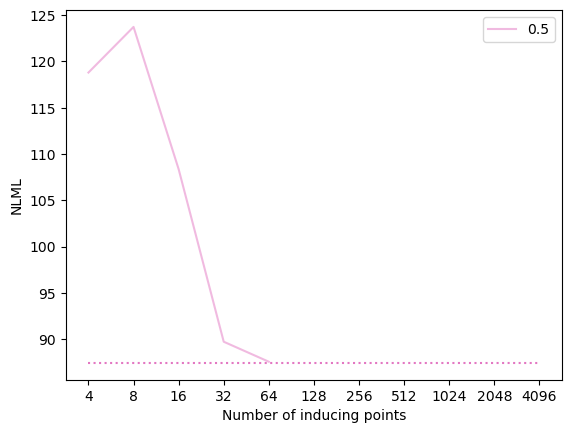

(11, 2)


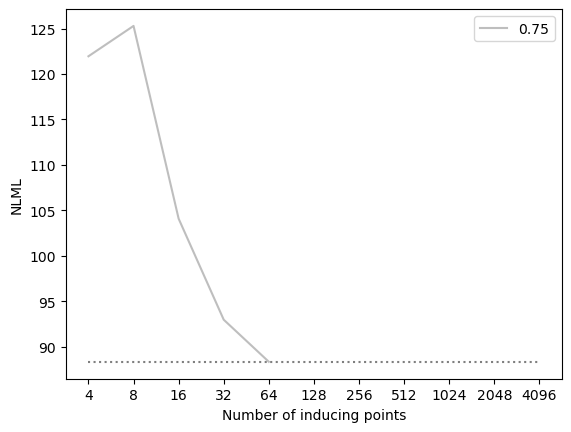

(11, 2)


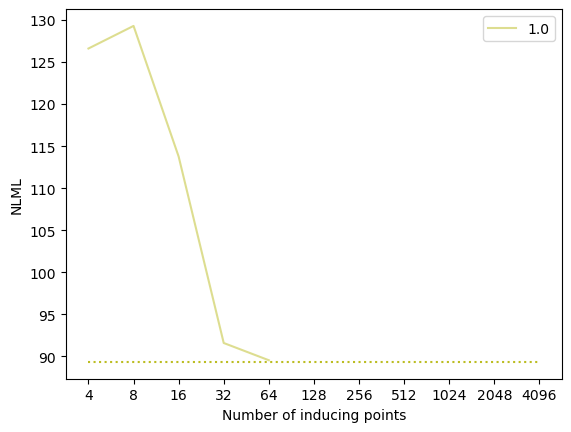

In [7]:
import matplotlib.colors as mcolors
colorlist = list(mcolors.TABLEAU_COLORS.values())
for j, l in enumerate(lmls):
    print(l.shape)
    plt.plot(exponents, -l[:,0], color=colorlist[j], alpha=0.5, label=cross_cov[j])
    plt.plot(exponents, -l[:,1], color=colorlist[j], linestyle=":")
    plt.xticks(exponents, 2 ** exponents)
    plt.xlabel("Number of inducing points")
    plt.ylabel("NLML")
    plt.legend()
    plt.show()

Observation: if we set W well, we can get monotonous results for increasing the IVs, but that is not a guarantee. In the limit, we do really approach the correct LML.